# Import Modules

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Load dataset

In [2]:
df = pd.read_csv("bank-full.csv", sep=";")

# Encode categorical variables

In [3]:
df_encoded = df.copy()
label_encoders = {}
for col in df_encoded.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# Features and target

In [4]:
X = df_encoded.drop("y", axis=1)
y = df_encoded["y"]

# Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models

In [7]:
knn = KNeighborsClassifier(n_neighbors=5)
svm_linear = SVC(kernel="linear", random_state=42)
svm_rbf = SVC(kernel="rbf", random_state=42)


# Train

In [8]:
knn.fit(X_train_scaled, y_train)
svm_linear.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)

SVC(random_state=42)

# Predictions

In [9]:
y_pred_knn = knn.predict(X_test_scaled)
y_pred_svm_linear = svm_linear.predict(X_test_scaled)
y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)

# Confusion matrices and reports

In [10]:
results = {
    "KNN": {
        "confusion_matrix": confusion_matrix(y_test, y_pred_knn),
        "accuracy_score": accuracy_score(y_test, y_pred_knn)
    },
    "SVM Linear": {
        "confusion_matrix": confusion_matrix(y_test, y_pred_svm_linear),
        "accuracy_score": accuracy_score(y_test, y_pred_svm_linear)
    },
    "SVM RBF": {
        "confusion_matrix": confusion_matrix(y_test, y_pred_svm_rbf),
        "accuracy_score": accuracy_score(y_test, y_pred_svm_rbf)
    }
}

results

{'KNN': {'confusion_matrix': array([[7734,  251],
         [ 723,  335]], dtype=int64),
  'accuracy_score': 0.8922923808470641},
 'SVM Linear': {'confusion_matrix': array([[7985,    0],
         [1058,    0]], dtype=int64),
  'accuracy_score': 0.8830034280659074},
 'SVM RBF': {'confusion_matrix': array([[7837,  148],
         [ 782,  276]], dtype=int64),
  'accuracy_score': 0.8971580227800509}}

# Sample subset for faster visualization

In [11]:
df_sample = df_encoded.sample(n=5000, random_state=42)
X_sample = df_sample.drop("y", axis=1)
y_sample = df_sample["y"]

# Scale

In [12]:
X_sample_scaled = scaler.fit_transform(X_sample)

# PCA to 2D

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample_scaled)

# Split

In [14]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)


# Train models on PCA data

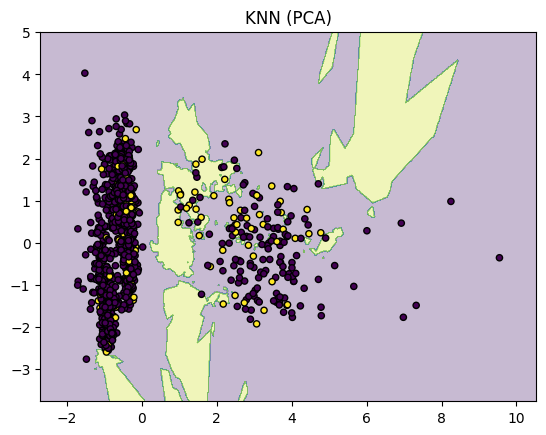

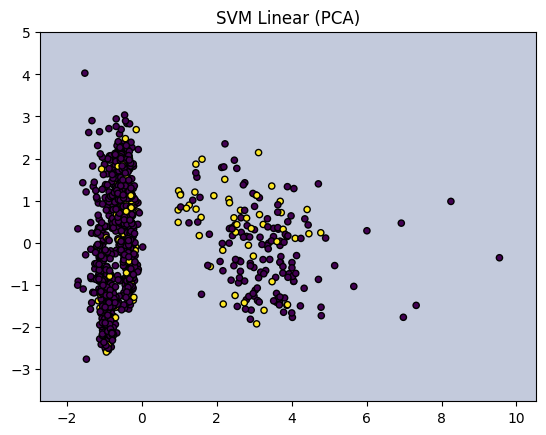

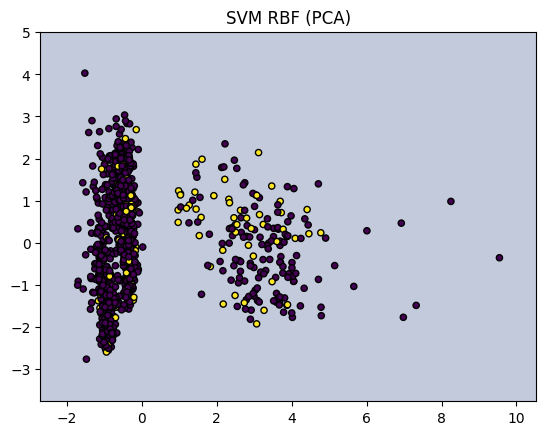

(array([[862,  19],
        [107,  12]], dtype=int64),
 array([[881,   0],
        [119,   0]], dtype=int64),
 array([[881,   0],
        [119,   0]], dtype=int64))

In [15]:
knn_pca = KNeighborsClassifier(n_neighbors=5)
svm_linear_pca = SVC(kernel="linear", random_state=42)
svm_rbf_pca = SVC(kernel="rbf", random_state=42)

knn_pca.fit(X_train_pca, y_train_pca)
svm_linear_pca.fit(X_train_pca, y_train_pca)
svm_rbf_pca.fit(X_train_pca, y_train_pca)

# Function to plot decision boundaries
def plot_decision_boundary(model, X, y, title):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=20)
    plt.title(title)


plot_decision_boundary(knn_pca, X_test_pca, y_test_pca, "KNN (PCA)")
plt.show()
plot_decision_boundary(svm_linear_pca, X_test_pca, y_test_pca, "SVM Linear (PCA)")
plt.show()
plot_decision_boundary(svm_rbf_pca, X_test_pca, y_test_pca, "SVM RBF (PCA)")
plt.show()

# Confusion matrices
cm_knn = confusion_matrix(y_test_pca, knn_pca.predict(X_test_pca))
cm_svm_linear = confusion_matrix(y_test_pca, svm_linear_pca.predict(X_test_pca))
cm_svm_rbf = confusion_matrix(y_test_pca, svm_rbf_pca.predict(X_test_pca))

cm_knn, cm_svm_linear, cm_svm_rbf
